# 03 · Univariate Forecasting — Baselines, ETS, ARIMA/SARIMA, auto_arima

## Part 3 — Univariate Forecasting

Forecasting is *one* series predicting *its own* future from its past. Part 2 gave us the
diagnostic toolkit; here we turn it into predictions and, crucially, **measure** them honestly.

The progression — each model adds one idea:

| family | captures | key models |
|---|---|---|
| **Baselines** | "tomorrow ≈ today" | naive, seasonal-naive, drift, mean |
| **ETS** (exponential smoothing) | level + trend + seasonality, weighted to recency | SES → Holt → Holt-Winters |
| **ARIMA** | autocorrelation structure of a stationarised series | AR, MA, ARIMA(p,d,q) |
| **SARIMA** | ARIMA + a seasonal copy of itself | SARIMA(p,d,q)(P,D,Q)ₘ |

We forecast two very different series on purpose:
- **Mauna Loa CO₂** — strong trend + seasonality ⇒ the "real" models should win big.
- **S&P 500 returns** — a near-random walk ⇒ a *reality check* where nothing beats the baseline.

> **Library note.** The classic `auto_arima` lives in **pmdarima**, but pmdarima is not
> compatible with NumPy 2.x (which this project uses), so we use **statsforecast's `AutoARIMA`**
> — the actively-maintained, NumPy-2-safe successor — alongside hand-built ARIMA via statsmodels.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import ts, forecasting as fc
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsforecast.models import AutoARIMA
from statsmodels.datasets import co2

# Two targets: a forecastable series (CO2) and a (nearly un-)forecastable one (S&P returns).
co2m = co2.load_pandas().data["co2"].resample("MS").mean().interpolate()
shiller = data.clean_shiller()
ret = shiller["return"].dropna()
H, M = 24, 12                       # 24-month horizon, 12-month season
tr, te = fc.ts_train_test(co2m, H)
print("CO2 train:", tr.index.min().date(), "->", tr.index.max().date(), "| test:", len(te), "months")


setup ok | numpy 2.1.3 | pandas 2.3.3


CO2 train: 1958-03-01 -> 1999-12-01 | test: 24 months


### 1. The workflow, the split, and how to score a forecast

**Split by time, never shuffle.** The test set must lie strictly *after* the training set —
otherwise the model peeks at the future (leakage) and the score is a fantasy. We hold out the
last `H` observations.

**Metrics** (computed on the held-out test set):

| metric | units | watch out |
|---|---|---|
| **MAE** | series units | robust, interpretable |
| **RMSE** | series units | punishes large misses (squared) |
| **MAPE** | % | **explodes when values cross 0** — useless for returns |
| **sMAPE** | % | symmetric, bounded, still odd near 0 |
| **MASE** | ratio | MAE ÷ in-sample naive MAE — **<1 beats naive**, comparable across series |

MASE is the one to trust: it bakes the naive baseline into the denominator, so a value below 1
literally means "better than doing nothing".

### 2. Baselines — the bar every model must clear

A forecast is only impressive *relative to the trivial alternative*. Four baselines, each
optimal for a different world:

- **naive** — repeat the last value. Optimal for a pure random walk (e.g. prices).
- **seasonal-naive** — repeat the value from one season ago. Optimal when seasonality dominates.
- **drift** — extend the line from first to last training point. A naive with slope.
- **mean** — the historical average. Optimal for flat noise around a constant level.

If your fancy model cannot beat the best of these, it has earned nothing.

                    MAE     RMSE   MAPE%  sMAPE%     MASE
seasonal_naive   1.8823   2.0665  0.5084  0.5100   1.4496
drift            1.9108   2.1815  0.5155  0.5165   1.4715
naive            2.4202   2.9291  0.6518  0.6548   1.8638
mean            31.9457  32.0037  8.6290  9.0194  24.6019


C:\Users\parth\Advanced-EDA\src\forecasting.py:87: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\parth\Advanced-EDA\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)


C:\Users\parth\Advanced-EDA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


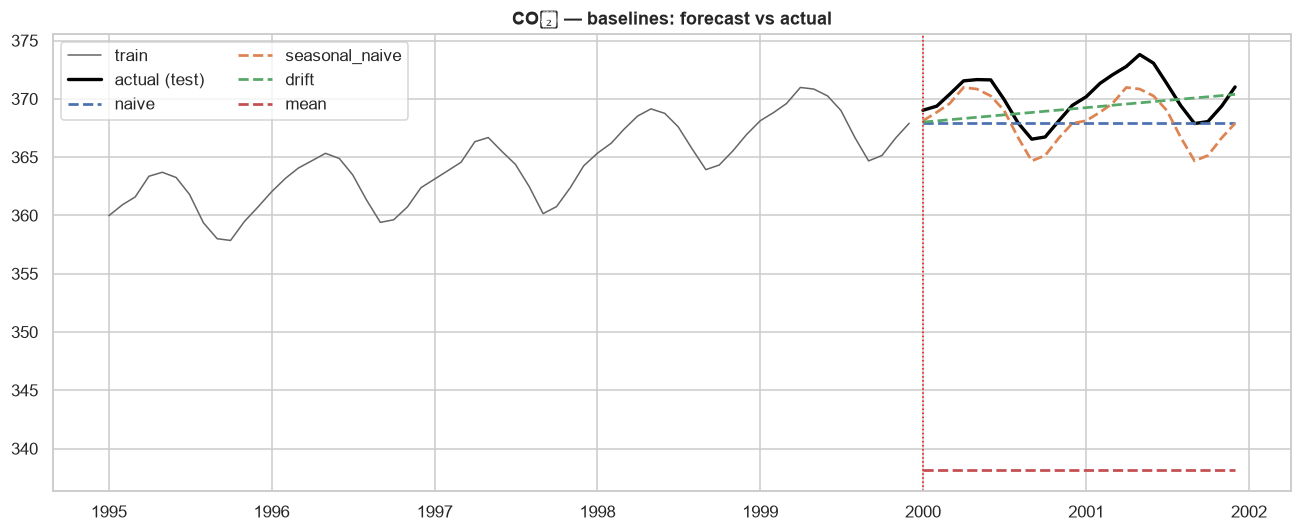

In [2]:
base = fc.baseline_forecasts(tr, H, M)
print(fc.compare_models(te, base, tr, m=M).to_string())
fig = fc.plot_forecast(tr, te, base, "CO₂ — baselines", "p3_co2_baselines.png", tail=60)
plt.show()

On CO₂ every baseline struggles: the series both **trends** and is **seasonal**, so repeating
the past (naive/seasonal-naive) lags the rising trend, and the **mean** is hopeless (MASE ≈ 25 —
the historical average sits far below today's level). This is the gap the real models will close.

### 3. ETS — exponential smoothing (level, trend, seasonality)

Exponential smoothing forecasts a weighted average of past values where **weights decay
geometrically** into the past (recent points matter more). It builds up in three steps:

- **SES** (Simple) — tracks the **level** only. Flat forecast. For series with no trend/season.
- **Holt** — adds a **trend** component. Forecast is a sloped line.
- **Holt-Winters** — adds a **seasonal** component (additive or multiplicative).

The modern name is **ETS** = (Error, Trend, Seasonal), each ∈ {None, Additive, Multiplicative};
that taxonomy of 30+ models is what `statsmodels`/`statsforecast` search over. Watch the three
levels build up on CO₂:

                            MAE     RMSE   MAPE%  sMAPE%     MASE
Holt-Winters (+season)   0.2357   0.3070  0.0636  0.0636   0.1815
SES (level)              2.4202   2.9291  0.6518  0.6548   1.8638
Holt (+trend)           13.4177  15.9691  3.6269  3.5363  10.3332


C:\Users\parth\Advanced-EDA\src\forecasting.py:87: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\parth\Advanced-EDA\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)


C:\Users\parth\Advanced-EDA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


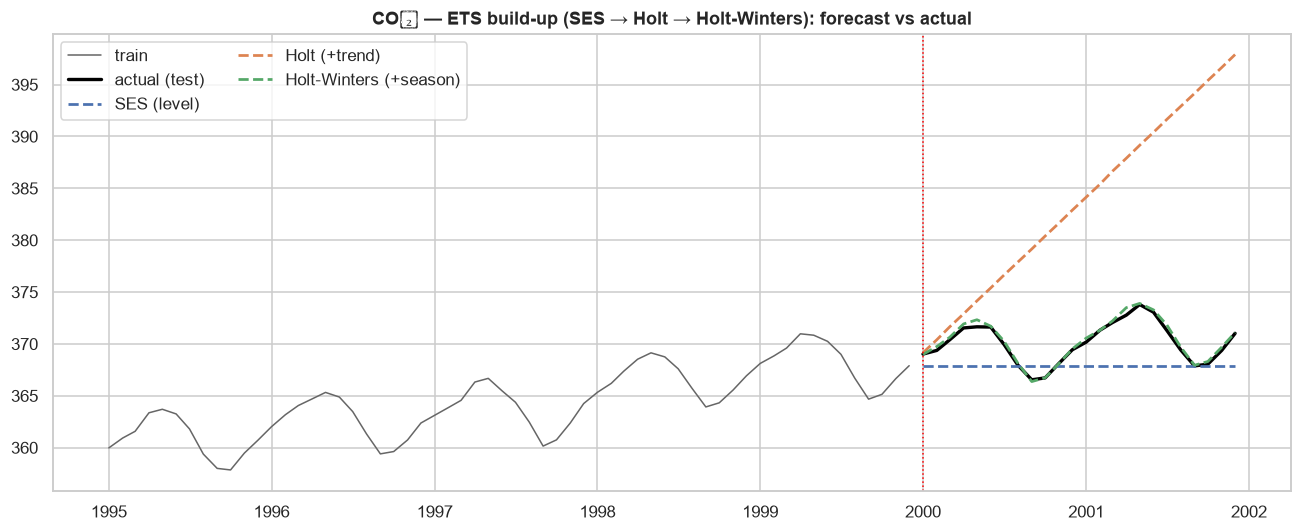

In [3]:
ets = {}
ets["SES (level)"]            = SimpleExpSmoothing(tr).fit().forecast(H).values
ets["Holt (+trend)"]         = Holt(tr).fit().forecast(H).values
ets["Holt-Winters (+season)"] = ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=M).fit().forecast(H).values
print(fc.compare_models(te, ets, tr, m=M).to_string())
fig = fc.plot_forecast(tr, te, ets, "CO₂ — ETS build-up (SES → Holt → Holt-Winters)", "p3_co2_ets.png", tail=60)
plt.show()

You can read the components straight off the plot: **SES** is flat (level only), **Holt**
slopes up (level + trend) but misses the wiggle, **Holt-Winters** tracks both the climb and the
annual cycle — MASE collapses from ~1.9 to ~0.18. Adding the right component is what buys accuracy.

### 4. ARIMA — modelling the autocorrelation itself

**ARIMA(p, d, q)** has three integers, and Part 2 already taught how to read them:

- **d** — how many times to **difference** to reach stationarity (from ADF×KPSS). CO₂ needs d=1.
- **p** — **AR** order: how many past *values* feed the prediction (PACF cut-off).
- **q** — **MA** order: how many past *forecast errors* feed it (ACF cut-off).

ARIMA assumes the (differenced) series is stationary and has **no seasonality** — so a plain
ARIMA on CO₂ will capture the trend (via d=1) but leave the yearly cycle in the residuals. That
failure is exactly what motivates SARIMA next.

plain ARIMA(2,1,2) on CO₂ — MASE 1.607 (captures trend, ignores season)


C:\Users\parth\Advanced-EDA\src\forecasting.py:87: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\parth\Advanced-EDA\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)


C:\Users\parth\Advanced-EDA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


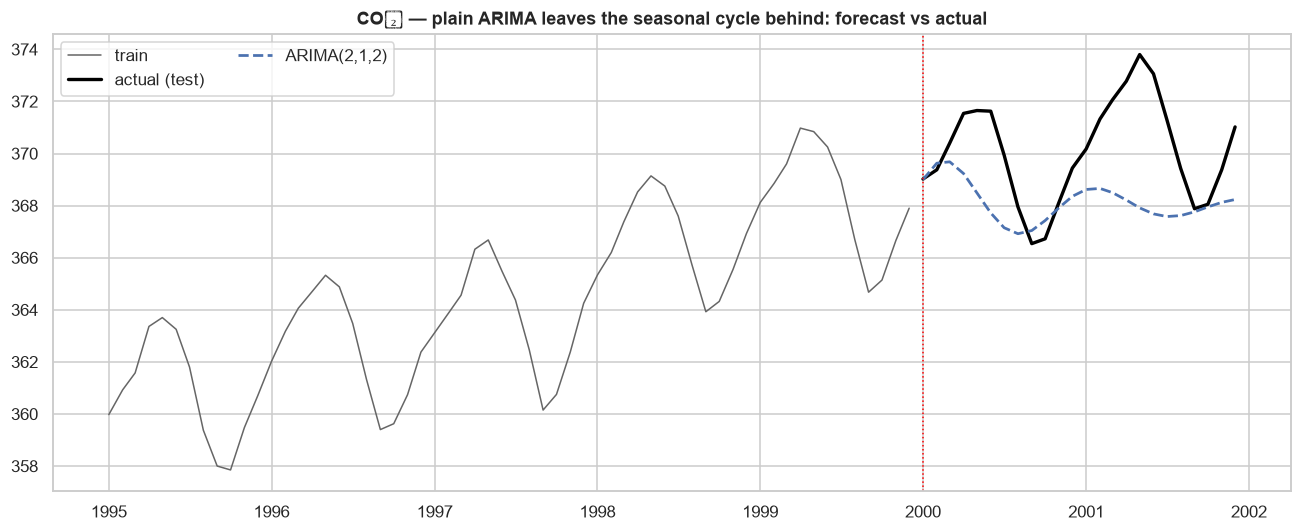

In [4]:
arima = SARIMAX(tr, order=(2, 1, 2), seasonal_order=(0, 0, 0, 0)).fit(disp=False)
pred_arima = arima.forecast(H).values
print("plain ARIMA(2,1,2) on CO₂ — MASE %.3f (captures trend, ignores season)"
      % fc.forecast_metrics(te.values, pred_arima, tr.values, M)["MASE"])
fig = fc.plot_forecast(tr, te, {"ARIMA(2,1,2)": pred_arima}, "CO₂ — plain ARIMA leaves the seasonal cycle behind",
                       "p3_co2_arima.png", tail=60)
plt.show()

### 5. SARIMA — ARIMA plus a seasonal copy

**SARIMA(p,d,q)(P,D,Q)ₘ** bolts a second, seasonal ARIMA onto the first: **(P,D,Q)** are the
seasonal AR/diff/MA orders and **m** is the period (12 for monthly data). **D=1** applies a
*seasonal difference* (value minus the value m steps ago) — in Part 2 we saw that flattens CO₂.

A sensible, classic specification is **SARIMA(1,1,1)(1,1,1)₁₂**; we confirm it below and let
`auto_arima` second-guess us in §7.

In [5]:
sarima = SARIMAX(tr, order=(1, 1, 1), seasonal_order=(1, 1, 1, M)).fit(disp=False)
pred_sarima = sarima.forecast(H).values
print("SARIMA(1,1,1)(1,1,1)12 — MASE %.3f" % fc.forecast_metrics(te.values, pred_sarima, tr.values, M)["MASE"])
print(sarima.summary().tables[0].as_text())

SARIMA(1,1,1)(1,1,1)12 — MASE 0.257
                                     SARIMAX Results                                      
Dep. Variable:                                co2   No. Observations:                  502
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -121.503
Date:                            Sat, 20 Jun 2026   AIC                            253.005
Time:                                    01:54:48   BIC                            273.967
Sample:                                03-01-1958   HQIC                           261.239
                                     - 12-01-1999                                         
Covariance Type:                              opg                                         


### 6. Box–Jenkins diagnostics — is the model *adequate*?

The Box–Jenkins loop is **identify → estimate → check → repeat**. A model is adequate when its
**residuals are white noise** — no structure left to extract. Four checks (statsmodels packs
them into `plot_diagnostics`):

1. **Residuals over time** — should look like patternless noise around 0.
2. **Histogram + KDE vs N(0,1)** — roughly normal.
3. **Q–Q plot** — points on the line.
4. **Correlogram (residual ACF)** — all spikes inside the band.

Plus the formal **Ljung–Box** test (H₀: residuals are uncorrelated) — we want **large** p-values.

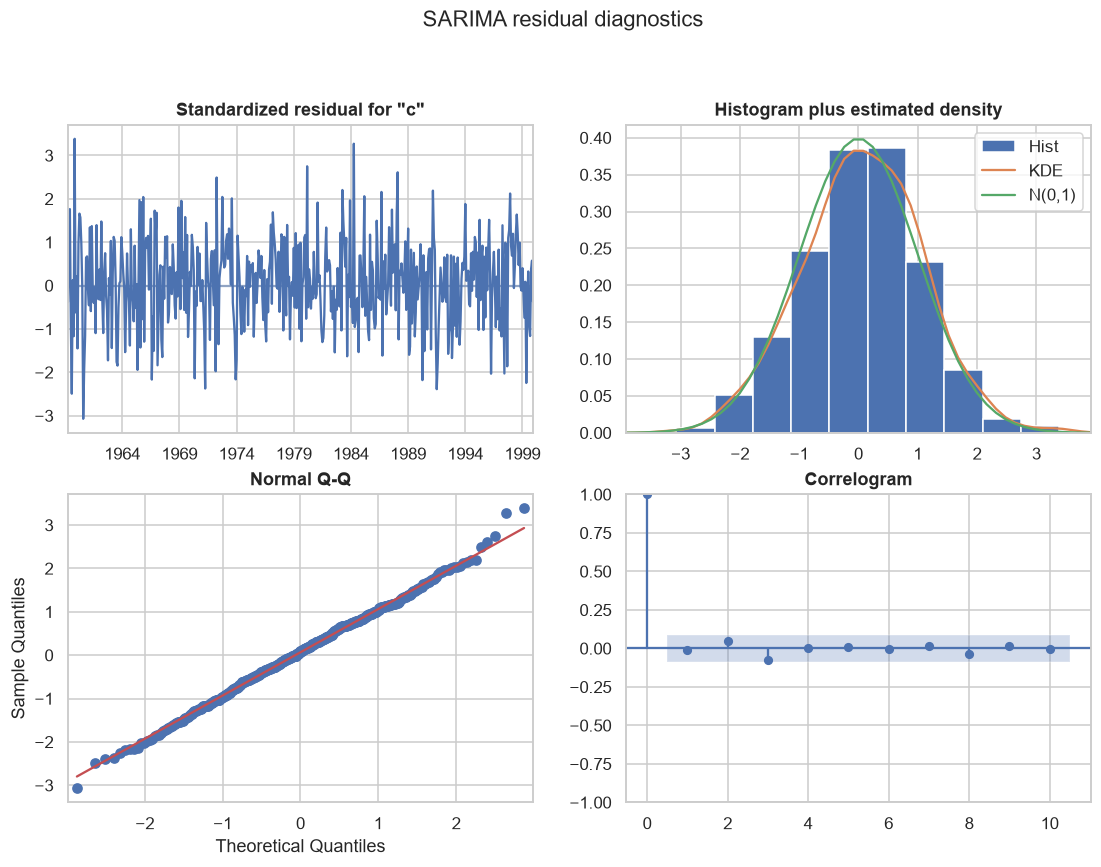

Ljung-Box on residuals (want p > 0.05 = white noise):
    lb_stat  lb_pvalue
12   8.7125     0.7273
24  20.3479     0.6768


In [6]:
fig = sarima.plot_diagnostics(figsize=(12, 8)); fig.suptitle("SARIMA residual diagnostics", y=1.01)
eda.savefig(fig, "p3_sarima_diagnostics.png"); plt.show()
lb = ts.ljung_box(sarima.resid.iloc[M+1:], lags=24)
print("Ljung-Box on residuals (want p > 0.05 = white noise):")
print(lb.loc[[12, 24]].to_string())

Residuals scatter around zero, sit on the Q–Q line, and the correlogram is clean — and the
Ljung–Box p-values are comfortably above 0.05. The model has wrung out the structure; what's left
is noise. That is the green light to forecast.

### 7. `auto_arima` — letting the computer search the orders

Manual Box–Jenkins is skillful but slow. **AutoARIMA** searches (p,d,q)(P,D,Q) by repeatedly
fitting and minimising an information criterion (**AIC** — fit penalised by parameter count), with
unit-root tests choosing d and D. It is what you reach for in production; the manual method is how
you understand and sanity-check it.

In [7]:
am = AutoARIMA(season_length=M, stepwise=True).fit(tr.values)
p, q, P, Q, m, d, D = am.model_["arma"]
print(f"AutoARIMA picked: ARIMA({p},{d},{q})({P},{D},{Q})[{m}]")
pred_auto = am.predict(h=H)["mean"]
print("AutoARIMA — MASE %.3f vs our manual SARIMA — MASE %.3f"
      % (fc.forecast_metrics(te.values, pred_auto, tr.values, M)["MASE"],
         fc.forecast_metrics(te.values, pred_sarima, tr.values, M)["MASE"]))

AutoARIMA picked: ARIMA(1,1,1)(2,1,1)[12]
AutoARIMA — MASE 0.248 vs our manual SARIMA — MASE 0.257


### 8. The leaderboard — every model on one CO₂ scoreboard

                            MAE     RMSE   MAPE%  sMAPE%     MASE
Holt-Winters             0.2357   0.3070  0.0636  0.0636   0.1815
AutoARIMA                0.3225   0.3919  0.0870  0.0870   0.2484
SARIMA(1,1,1)(1,1,1)12   0.3338   0.4095  0.0900  0.0900   0.2570
seasonal_naive           1.8823   2.0665  0.5084  0.5100   1.4496
drift                    1.9108   2.1815  0.5155  0.5165   1.4715
naive                    2.4202   2.9291  0.6518  0.6548   1.8638
mean                    31.9457  32.0037  8.6290  9.0194  24.6019


C:\Users\parth\Advanced-EDA\src\forecasting.py:87: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\parth\Advanced-EDA\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)


C:\Users\parth\Advanced-EDA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


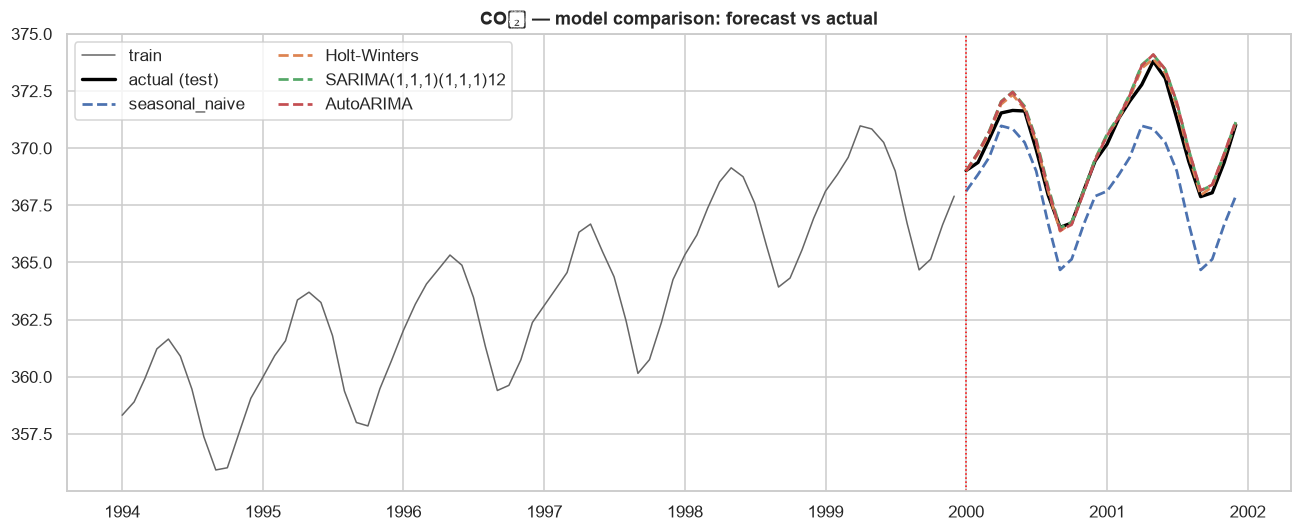

In [8]:
allp = {**base, "Holt-Winters": ets["Holt-Winters (+season)"],
        "SARIMA(1,1,1)(1,1,1)12": pred_sarima, "AutoARIMA": pred_auto}
board = fc.compare_models(te, allp, tr, m=M)
print(board.to_string())
fig = fc.plot_forecast(tr, te, {k: allp[k] for k in ["seasonal_naive", "Holt-Winters", "SARIMA(1,1,1)(1,1,1)12", "AutoARIMA"]},
                       "CO₂ — model comparison", "p3_co2_leaderboard.png", tail=72)
plt.show()

The structured models (Holt-Winters, SARIMA, AutoARIMA) beat every baseline by **~8×** on
MASE. On a series with genuine trend and seasonality, modelling pays off enormously.

### 9. Reality check — forecasting S&P 500 returns

Now the humbling half. Equity returns are close to a **random walk**: Part 2 showed they're
stationary with almost no usable autocorrelation. So what *should* win? The naive/mean baseline.
Let's see whether an ARIMA can beat doing nothing.

In [9]:
H2 = 60
trr, ter = fc.ts_train_test(ret, H2)
rp = {"mean": fc.baseline_forecasts(trr, H2, 1)["mean"],
      "naive": fc.baseline_forecasts(trr, H2, 1)["naive"],
      "ARIMA(1,0,1)": SARIMAX(trr, order=(1, 0, 1)).fit(disp=False).forecast(H2).values}
print(fc.compare_models(ter, rp, trr, m=1).to_string())

                 MAE    RMSE      MAPE%    sMAPE%    MASE
naive         0.0273  0.0342  1650.3532  144.9563  0.7940
mean          0.0277  0.0344  1208.7239  154.0811  0.8041
ARIMA(1,0,1)  0.0290  0.0355   100.2658  199.9986  0.8411


Two lessons land at once:

1. **ARIMA does *not* beat the mean** (MASE ≈ 0.84 vs ≈ 0.80). On an efficient, near-random series,
   sophistication buys nothing — sometimes it *hurts*. The honest forecast for next month's return
   is roughly its long-run average. This is *why* quant work targets **volatility and risk**
   (which Part 2 showed *is* predictable) rather than the direction of returns.
2. **Look at the MAPE column: ~1650%.** Because returns cross zero, dividing by them blows MAPE up
   into nonsense. This is the concrete reason we score forecasts with **MASE/MAE**, not MAPE.

### 10. Don't forecast a point — forecast a *range*

A single number is overconfident. A forecast needs a **prediction interval** that widens with the
horizon (uncertainty compounds). statsmodels gives model-based intervals directly; in Part 6 we'll
add **conformal** intervals that hold even when the model's assumptions don't.

C:\Users\parth\Advanced-EDA\src\forecasting.py:87: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\parth\Advanced-EDA\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)


C:\Users\parth\Advanced-EDA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


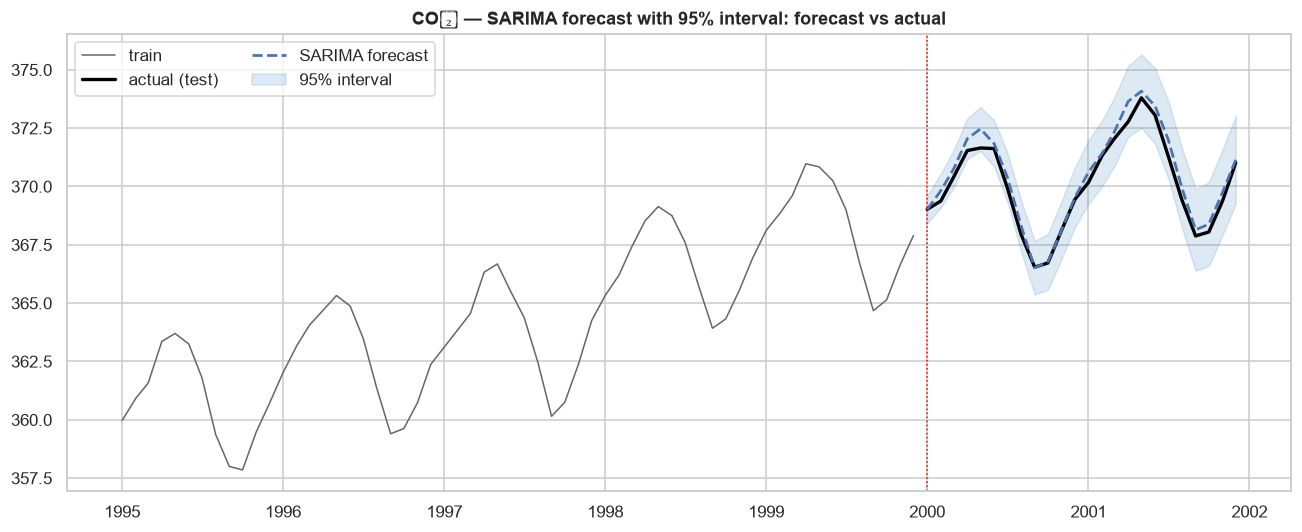

Actual test points inside the 95% interval: 100%


In [10]:
fcres = sarima.get_forecast(H)
mean = fcres.predicted_mean.values
ci = fcres.conf_int(alpha=0.05).values
fig = fc.plot_forecast(tr, te, {"SARIMA forecast": mean}, "CO₂ — SARIMA forecast with 95% interval",
                       "p3_co2_interval.png", tail=60, interval=(ci[:, 0], ci[:, 1]))
plt.show()
cover = ((te.values >= ci[:, 0]) & (te.values <= ci[:, 1])).mean()
print("Actual test points inside the 95%% interval: %.0f%%" % (100 * cover))

### Takeaways

- **Split by time and score with MASE.** A model only matters if it beats the naive baseline (MASE<1).
- **ETS** builds accuracy by *adding components*: level (SES) → trend (Holt) → seasonality (Holt-Winters).
- **ARIMA(p,d,q)** reads straight off Part 2: d from stationarity, p/q from PACF/ACF. **SARIMA** adds
  the seasonal `(P,D,Q)ₘ` block; **D=1** is the seasonal difference.
- **Box–Jenkins**: a model is adequate only when residuals are **white noise** (clean correlogram,
  large Ljung-Box p). `auto_arima` automates the search via AIC — understand it, then trust it.
- **CO₂**: structured models beat baselines ~8×. **S&P returns**: nothing beats the mean, and MAPE
  is meaningless — markets are (nearly) efficient, so we forecast *risk*, not *direction*.
- Always forecast an **interval**, not just a point.

**Next — Part 4 (Multivariate):** when series move *together*. Build a returns panel, find the market
factor with **PCA**, test lead/lag with **Granger causality**, and exploit long-run equilibria with
**cointegration / VECM** (the engine behind pairs trading).